IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df = pd.read_csv("fpds_data.csv", low_memory=False)
print(df)

                  contract_transaction_unique_key  \
0       9700_9700_SPE2DX21FEPUZ_0_SPE2DX19D5041_0   
1       9700_9700_SPE3SU21F693Z_0_SPE30018DS335_0   
2       4732_4732_47QMCA21F03NX_0_47QMCA20D004B_0   
3       4732_4732_47QSCC21F4BLQ_0_47QSCC21A0001_0   
4       9700_9700_SPE4A221F6549_0_SPE4AX19D9438_0   
...                                           ...   
235744  9700_9700_SPE2D621F018M_0_SPE2DE20D0008_0   
235745  9700_9700_SPE2DV21FAAT4_0_SPE2DV17D6030_0   
235746  9700_9700_SPE8EJ21F1243_0_SPE8EJ17D0001_0   
235747  9700_9700_SPE8EX21FW18U_0_SPE8EH19D0017_0   
235748  9700_9700_SPE3SU21F0LYL_0_SPE30020DRA75_0   

                             contract_award_unique_key  award_id_piid  \
0       CONT_AWD_SPE2DX21FEPUZ_9700_SPE2DX19D5041_9700  SPE2DX21FEPUZ   
1       CONT_AWD_SPE3SU21F693Z_9700_SPE30018DS335_9700  SPE3SU21F693Z   
2       CONT_AWD_47QMCA21F03NX_4732_47QMCA20D004B_4732  47QMCA21F03NX   
3       CONT_AWD_47QSCC21F4BLQ_4732_47QSCC21A0001_4732  47QSCC21F4BLQ  

In [3]:
df.head()

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,parent_award_agency_id,parent_award_agency_name,parent_award_id_piid,parent_award_modification_number,federal_action_obligation,...,highly_compensated_officer_2_name,highly_compensated_officer_2_amount,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,last_modified_date
0,9700_9700_SPE2DX21FEPUZ_0_SPE2DX19D5041_0,CONT_AWD_SPE2DX21FEPUZ_9700_SPE2DX19D5041_9700,SPE2DX21FEPUZ,0,0.0,9700,DEPT OF DEFENSE,SPE2DX19D5041,0,386.69,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_SPE...,2021-05-20 02:19:47
1,9700_9700_SPE3SU21F693Z_0_SPE30018DS335_0,CONT_AWD_SPE3SU21F693Z_9700_SPE30018DS335_9700,SPE3SU21F693Z,0,0.0,9700,DEPT OF DEFENSE,SPE30018DS335,0,620.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_SPE...,2021-03-09 19:45:23
2,4732_4732_47QMCA21F03NX_0_47QMCA20D004B_0,CONT_AWD_47QMCA21F03NX_4732_47QMCA20D004B_4732,47QMCA21F03NX,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QMCA20D004B,0,177625.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2021-01-29 21:19:04
3,4732_4732_47QSCC21F4BLQ_0_47QSCC21A0001_0,CONT_AWD_47QSCC21F4BLQ_4732_47QSCC21A0001_4732,47QSCC21F4BLQ,0,0.0,4732,FEDERAL ACQUISITION SERVICE,47QSCC21A0001,PS0001,18319.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/CONT_AWD_47Q...,2021-07-15 05:09:33
4,9700_9700_SPE4A221F6549_0_SPE4AX19D9438_0,CONT_AWD_SPE4A221F6549_9700_SPE4AX19D9438_9700,SPE4A221F6549,0,0.0,9700,DEPT OF DEFENSE,SPE4AX19D9438,0,4598.30,...,JACK ROVAN,150529.0,KELLY WALSH,130000.0,TERRY HOGAN,123822.0,ALAN BORING,120182.0,https://www.usaspending.gov/award/CONT_AWD_SPE...,2022-02-13 06:34:20


In [4]:
df.shape

(235749, 284)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235749 entries, 0 to 235748
Columns: 284 entries, contract_transaction_unique_key to last_modified_date
dtypes: float64(22), int64(4), object(258)
memory usage: 510.8+ MB


DATA CLEANING

In [6]:
# Convert date column
df['action_date'] = pd.to_datetime(df['action_date'], errors='coerce')

In [7]:
# Extract year
df['year'] = df['action_date'].dt.year

In [8]:
# Handle missing values
df = df.dropna(subset=[
    'recipient_name',
    'awarding_agency_name',
    'federal_action_obligation'
])


In [9]:
# Remove negative or zero contracts
df = df[df['federal_action_obligation'] > 0]

In [10]:
# Clean column names
df.columns = df.columns.str.lower().str.strip()

In [12]:
# Select only important columns

useful_columns = [
    'recipient_name',
    'awarding_agency_name',
    'federal_action_obligation',
    'total_dollars_obligated',
    'base_and_exercised_options_value',
    'action_date',
    'recipient_state_name',
    'recipient_country_name',
    'naics_description',
    'award_description',
    'contracting_officers_determination_of_business_size'
]

df = df[useful_columns]

In [13]:
# Remove rows with critical missing values
df = df.dropna(subset=[
    'recipient_name',
    'awarding_agency_name',
    'federal_action_obligation'
])

In [14]:
# Convert date column
df['action_date'] = pd.to_datetime(df['action_date'], errors='coerce')

In [15]:
# Extract year
df['year'] = df['action_date'].dt.year

In [16]:
# Remove zero or negative contract values
df = df[df['federal_action_obligation'] > 0]

In [17]:
# Rename columns

df = df.rename(columns={
    'recipient_name': 'vendor',
    'awarding_agency_name': 'agency',
    'federal_action_obligation': 'contract_value',
    'recipient_state_name': 'state',
    'naics_description': 'industry'
})

In [18]:
# Save Clean Dataset

df.to_csv("clean_fpds_data.csv", index=False)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("clean_fpds_data.csv")
print(df)

                                               vendor  \
0                  AMERISOURCEBERGEN DRUG CORPORATION   
1       OAKES FARMS FOOD & DISTRIBUTION SERVICES, LLC   
2                                  FORD MOTOR COMPANY   
3                                 W.W. GRAINGER, INC.   
4                          MARTIN-BAKER AMERICA, INC.   
...                                               ...   
204492                 VERMILION VALLEY PRODUCE, INC.   
204493                        DOVE MEDICAL SUPPLY LLC   
204494               OWENS & MINOR DISTRIBUTION, INC.   
204495                   ATLANTIC DIVING SUPPLY, INC.   
204496                          NOBLE SALES CO., INC.   

                                       agency  contract_value  \
0                 DEPARTMENT OF DEFENSE (DOD)          386.69   
1                 DEPARTMENT OF DEFENSE (DOD)          620.34   
2       GENERAL SERVICES ADMINISTRATION (GSA)       177625.00   
3       GENERAL SERVICES ADMINISTRATION (GSA)        18

In [21]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204497 entries, 0 to 204496
Data columns (total 12 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   vendor                                               204497 non-null  object 
 1   agency                                               204497 non-null  object 
 2   contract_value                                       204497 non-null  float64
 3   total_dollars_obligated                              204497 non-null  float64
 4   base_and_exercised_options_value                     204294 non-null  float64
 5   action_date                                          204497 non-null  object 
 6   state                                                202917 non-null  object 
 7   recipient_country_name                               204488 non-null  object 
 8   industry                                             2

In [22]:
# Shape of dataset
df.shape

(204497, 12)

In [23]:
# Summary statistics
df.describe()

,contract_value,total_dollars_obligated,base_and_exercised_options_value,year
count,2.044970e+05,2.044970e+05,2.042940e+05,204497.000000
mean,1.423057e+05,4.174550e+06,1.231866e+05,2020.786369
std,1.256672e+07,2.257017e+08,1.230113e+07,0.409871
min,1.000000e-02,0.000000e+00,-9.291128e+07,2020.000000
25%,1.447200e+02,1.420200e+02,1.319850e+02,2021.000000
50%,5.000000e+02,5.026400e+02,4.695000e+02,2021.000000
75%,3.336310e+03,3.726720e+03,2.868967e+03,2021.000000
max,5.380286e+09,3.451328e+10,5.379141e+09,2021.000000


In [25]:
# Fill with Median
df['base_and_exercised_options_value'].fillna(
    df['base_and_exercised_options_value'].median(),
    inplace=True
)

/tmp/ipykernel_1117/3590963975.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['base_and_exercised_options_value'].fillna(


In [26]:
# Handle State column

df['state'].fillna("Unknown", inplace=True)

/tmp/ipykernel_1117/2931265991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['state'].fillna("Unknown", inplace=True)


In [27]:
# Country Column

df['recipient_country_name'].fillna(
    df['recipient_country_name'].mode()[0],
    inplace=True
)

/tmp/ipykernel_1117/1694448834.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['recipient_country_name'].fillna(


In [28]:
# Industry Column

df['industry'].fillna("Unknown", inplace=True)

/tmp/ipykernel_1117/3286490250.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['industry'].fillna("Unknown", inplace=True)


In [29]:
# Award Description

df['award_description'].fillna("Not Specified", inplace=True)

/tmp/ipykernel_1117/1291735230.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['award_description'].fillna("Not Specified", inplace=True)


In [30]:
df.isnull().sum()

,0
vendor,0
agency,0
contract_value,0
total_dollars_obligated,0
base_and_exercised_options_value,0
action_date,0
state,0
recipient_country_name,0
industry,0
award_description,0


In [31]:
# Save final clean data

df.to_csv("clean_fpds_data.csv", index=False)

Basic EDA

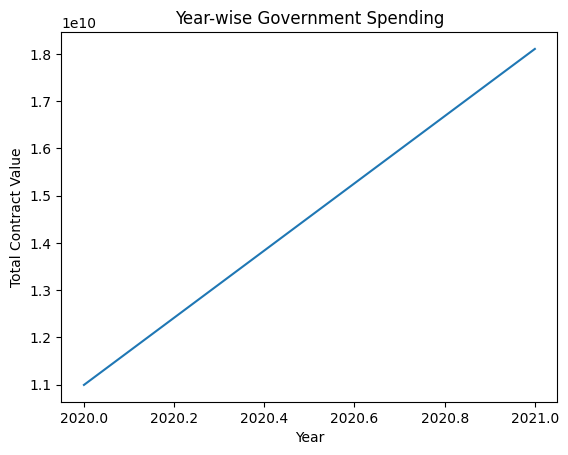

In [32]:
# 1. Yearly spending Trend

yearly_spending = df.groupby('year')['contract_value'].sum()

plt.figure()
yearly_spending.plot()
plt.title("Year-wise Government Spending")
plt.xlabel("Year")
plt.ylabel("Total Contract Value")
plt.show()

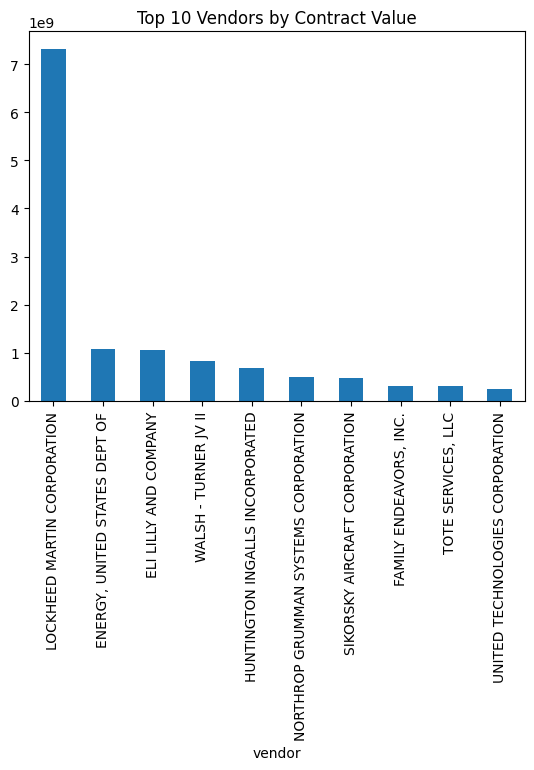

In [33]:
# Top 10 Vendors

top_vendors = df.groupby('vendor')['contract_value'] \
                .sum().sort_values(ascending=False).head(10)

plt.figure()
top_vendors.plot(kind='bar')
plt.title("Top 10 Vendors by Contract Value")
plt.show()

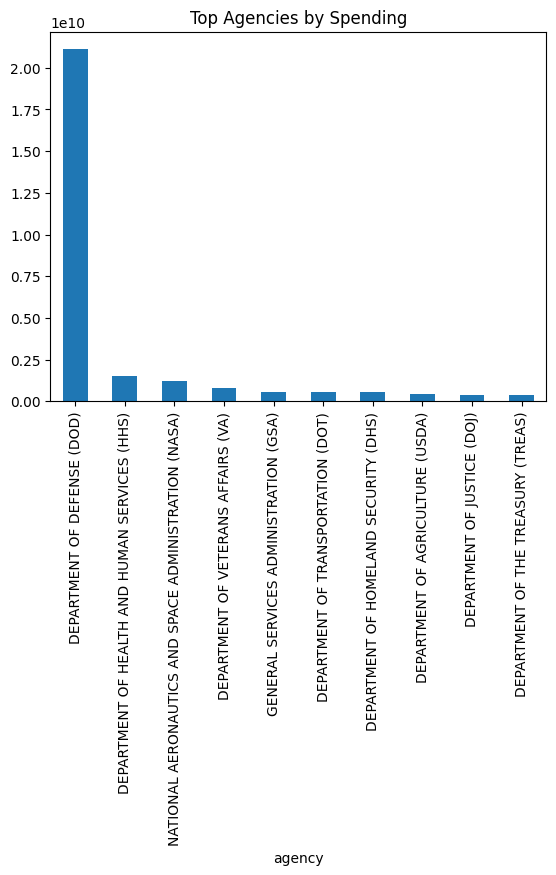

In [34]:
# Top Agencies

top_agencies = df.groupby('agency')['contract_value'] \
                 .sum().sort_values(ascending=False).head(10)

plt.figure()
top_agencies.plot(kind='bar')
plt.title("Top Agencies by Spending")
plt.show()

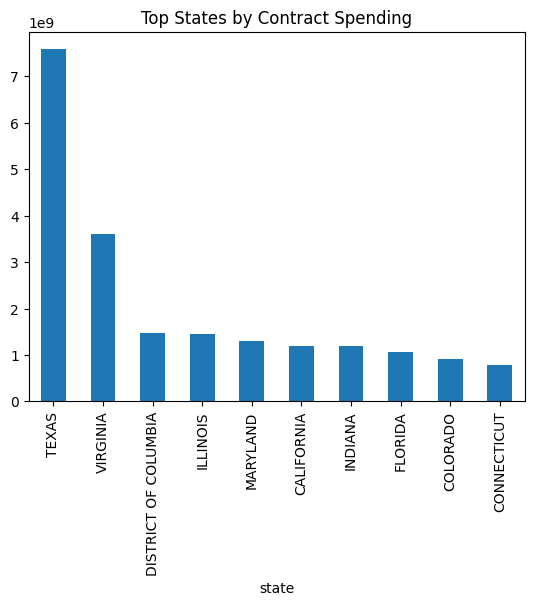

In [35]:
# tate - Wise Analysis

state_spending = df.groupby('state')['contract_value'] \
                   .sum().sort_values(ascending=False).head(10)

plt.figure()
state_spending.plot(kind='bar')
plt.title("Top States by Contract Spending")
plt.show()

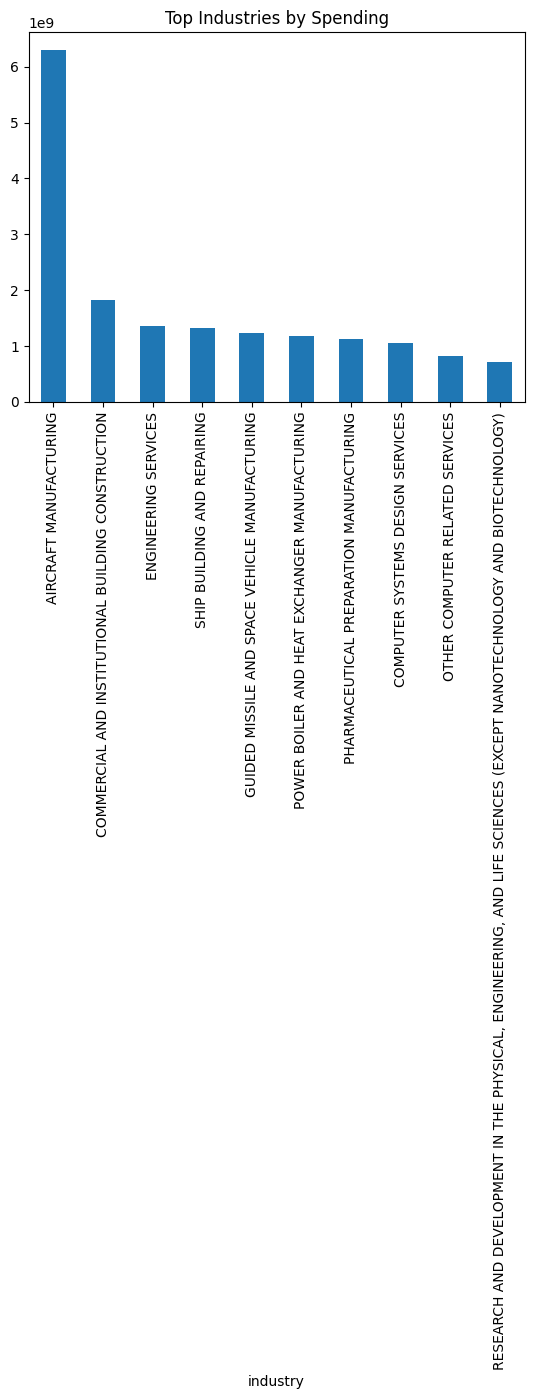

In [36]:
# Industry Analysis

industry = df.groupby('industry')['contract_value'] \
             .sum().sort_values(ascending=False).head(10)

plt.figure()
industry.plot(kind='bar')
plt.title("Top Industries by Spending")
plt.show()

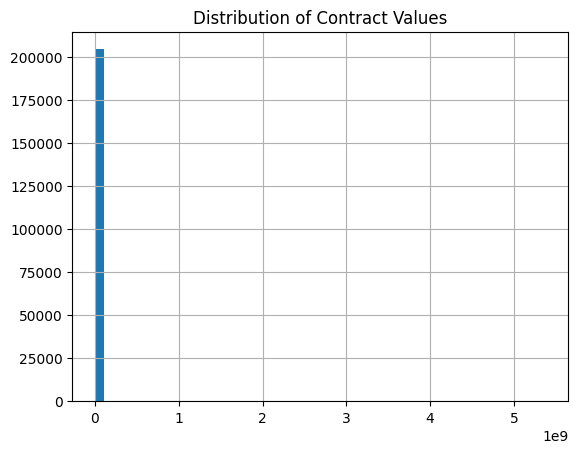

In [37]:
# Contract Value Distribution

plt.figure()
df['contract_value'].hist(bins=50)
plt.title("Distribution of Contract Values")
plt.show()

In [38]:
# Vendor Performance Analysis

vendor_perf = df.groupby('vendor').agg({
    'contract_value': ['sum', 'count']
})

vendor_perf.columns = ['total_value', 'total_contracts']

vendor_perf['avg_contract_value'] = (
    vendor_perf['total_value'] / vendor_perf['total_contracts']
)

vendor_perf.sort_values(by='total_value', ascending=False).head(10)

,total_value,total_contracts,avg_contract_value
vendor,,,
LOCKHEED MARTIN CORPORATION,7.315251e+09,279,2.621954e+07
"ENERGY, UNITED STATES DEPT OF",1.071074e+09,2,5.355370e+08
ELI LILLY AND COMPANY,1.062500e+09,2,5.312500e+08
WALSH - TURNER JV II,8.401303e+08,1,8.401303e+08
HUNTINGTON INGALLS INCORPORATED,6.908647e+08,37,1.867202e+07
NORTHROP GRUMMAN SYSTEMS CORPORATION,4.932910e+08,199,2.478849e+06
SIKORSKY AIRCRAFT CORPORATION,4.832924e+08,1104,4.377648e+05
"FAMILY ENDEAVORS, INC.",3.034180e+08,2,1.517090e+08
"TOTE SERVICES, LLC",3.029389e+08,8,3.786736e+07


In [39]:
# Outlier Detection

threshold = df['contract_value'].quantile(0.99)

outliers = df[df['contract_value'] > threshold]

outliers[['vendor', 'contract_value']].head()

,vendor,contract_value
6,"EMMES CORPORATION, THE",6345402.87
48,AIR NEW ZEALAND ENGINEERING SERVICES,2017173.43
75,PANACEA CONSTRUCTION GROUP LLC,1485588.24
96,ULTRA ELECTRONICS OCEAN SYSTEMS INC,4631701.00
116,"GRYPHON TECHNOLOGIES, L.C.",1544418.00
